# CS541 Challenge — Student Starter Baseline


This notebook provides a simple baseline students can extend.

What this starter includes:
- CIFAR-100 train/val/test pipeline
- A basic CNN baseline model
- Training + validation loop
- OOD inference and submission file generation

What students should improve:
- Better model architectures
- Better optimization schedules
- Better regularization and augmentation
- Better OOD robustness


## Part 1: Build Your Own CNN

In [1]:
# Runtime configuration
FAST_DEV_RUN = False  # True = quick smoke test
SEED = 42

import os

IN_COLAB = False
try:
    import google.colab  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

WORK_ROOT = "/content" if IN_COLAB else os.path.abspath("./temp_student")
os.makedirs(WORK_ROOT, exist_ok=True)

DATA_ROOT = os.path.join(WORK_ROOT, "data")
OOD_DIR = os.path.join(WORK_ROOT, "ood-test-CS541")
SUBMISSION_PATH = os.path.join(WORK_ROOT, "submission_ood.csv")

print("IN_COLAB:", IN_COLAB)
print("WORK_ROOT:", WORK_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("OOD_DIR:", OOD_DIR)
print("SUBMISSION_PATH:", SUBMISSION_PATH)


IN_COLAB: False
WORK_ROOT: /teamspace/studios/this_studio/temp_student
DATA_ROOT: /teamspace/studios/this_studio/temp_student/data
OOD_DIR: /teamspace/studios/this_studio/temp_student/ood-test-CS541
SUBMISSION_PATH: /teamspace/studios/this_studio/temp_student/submission_ood.csv


In [2]:
# Install required packages (safe to re-run)
import importlib.util
import subprocess
import sys

required = ["torch", "torchvision", "tqdm", "numpy", "pandas", "matplotlib", "huggingface_hub"]
missing = [p for p in required if importlib.util.find_spec(p) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", *missing])

print("Environment ready")


Environment ready


In [3]:
import os
import random
from typing import Dict, Optional, Tuple

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from tqdm.auto import tqdm


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def get_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")


def accuracy_top1(logits: torch.Tensor, targets: torch.Tensor) -> float:
    return (logits.argmax(dim=1) == targets).float().mean().item()


def make_loaders(batch_size: int, num_workers: int) -> Tuple[DataLoader, DataLoader, DataLoader]:
    mean = (0.5071, 0.4867, 0.4408) ### DO NOT CHANGE THIS
    std = (0.2675, 0.2565, 0.2761)  ### DO NOT CHANGE THIS

    # --- UPGRADED: augmentation on training data for better generalization ---
    # RandomCrop with padding + horizontal flip are standard CIFAR augmentations.
    # ColorJitter adds brightness/contrast/saturation variation, improving OOD robustness.
    # RandomErasing randomly masks out patches, acting like a regularizer (Cutout-style).
    train_tfms = transforms.Compose([
        transforms.RandomCrop(32, padding=4),          # crop after zero-padding edges
        transforms.RandomHorizontalFlip(),              # flip left-right with 50% prob
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
        transforms.RandomErasing(p=0.25, scale=(0.02, 0.2)),  # erase random patches
    ])

    # Eval/test: no augmentation, just normalize
    eval_tfms = transforms.Compose([transforms.ToTensor(), transforms.Normalize(mean, std)])

    train_full = datasets.CIFAR100(root=DATA_ROOT, train=True, download=True, transform=train_tfms)
    test_ds    = datasets.CIFAR100(root=DATA_ROOT, train=False, download=True, transform=eval_tfms)

    n       = len(train_full)
    n_train = int(0.8 * n)
    n_val   = n - n_train
    g       = torch.Generator().manual_seed(SEED)
    train_ds, val_ds = torch.utils.data.random_split(train_full, [n_train, n_val], generator=g)

    if FAST_DEV_RUN:
        train_ds = torch.utils.data.Subset(train_ds, range(min(2048, len(train_ds))))
        val_ds   = torch.utils.data.Subset(val_ds,   range(min(1024, len(val_ds))))
        test_ds  = torch.utils.data.Subset(test_ds,  range(min(1024, len(test_ds))))

    if IN_COLAB:
        num_workers = 0

    pin = torch.cuda.is_available()
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=num_workers, pin_memory=pin)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin)
    return train_loader, val_loader, test_loader


# ---------------------------------------------------------------------------
# Part 1: Custom CNN built from scratch
# ---------------------------------------------------------------------------
# Architecture: 5-block ResNet-style CNN with:
#   - Residual (skip) connections to help gradients flow through deeper layers
#   - Batch Normalization after every conv for stable, faster training
#   - Global Average Pooling instead of Flatten to reduce parameters and overfit less
#   - Dropout before the final classifier for regularization
# This is meaningfully deeper and more capable than the 3-block SimpleCNN baseline.
# ---------------------------------------------------------------------------

class ResidualBlock(nn.Module):
    """
    A single residual block: two conv layers with BN + ReLU, plus a skip connection.
    If in_channels != out_channels (or stride > 1), a 1x1 conv projection aligns the skip.
    """
    def __init__(self, in_channels: int, out_channels: int, stride: int = 1):
        super().__init__()
        # Main path: conv -> BN -> ReLU -> conv -> BN
        self.main = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
        )
        # Skip path: identity if channels match, else 1x1 conv to project dimensions
        if stride != 1 or in_channels != out_channels:
            self.skip = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )
        else:
            self.skip = nn.Identity()

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Add skip connection output to main path output, then activate
        return self.relu(self.main(x) + self.skip(x))


class DeepCNN(nn.Module):
    """
    5-block custom CNN for CIFAR-100 (Part 1).

    Block structure:
      stem  : 3  -> 64  channels, 3x3 conv + BN + ReLU (no pool, CIFAR is small)
      block1: 64  -> 64  (2 residual blocks, stride=1)
      block2: 64  -> 128 (2 residual blocks, stride=2 to downsample)
      block3: 128 -> 256 (2 residual blocks, stride=2)
      block4: 256 -> 512 (2 residual blocks, stride=2)
      head  : Global Average Pool -> Dropout(0.4) -> Linear(512, 100)

    Total: 5 macro-blocks (stem + 4 stages), satisfying the >2 block requirement.
    """
    def __init__(self, num_classes: int = 100):
        super().__init__()

        # Stem: initial feature extraction without aggressive downsampling
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )

        # 4 stages of residual blocks, progressively doubling channels
        self.stage1 = nn.Sequential(ResidualBlock(64, 64),  ResidualBlock(64, 64))
        self.stage2 = nn.Sequential(ResidualBlock(64, 128, stride=2), ResidualBlock(128, 128))
        self.stage3 = nn.Sequential(ResidualBlock(128, 256, stride=2), ResidualBlock(256, 256))
        self.stage4 = nn.Sequential(ResidualBlock(256, 512, stride=2), ResidualBlock(512, 512))

        # Head: global average pool collapses spatial dims to 1x1, then classify
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),   # output: (batch, 512, 1, 1)
            nn.Flatten(),              # -> (batch, 512)
            nn.Dropout(0.4),           # regularization before final layer
            nn.Linear(512, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        return self.head(x)


def fit(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    device: torch.device,
    epochs: int,
    scheduler=None,
) -> Dict[str, list]:
    """Training loop with optional LR scheduler support and best-model checkpointing."""
    history = {"train_acc": [], "val_acc": [], "train_loss": [], "val_loss": []}
    best_val_acc = -1.0
    best_state   = None

    for epoch in range(1, epochs + 1):
        # --- Training phase ---
        model.train()
        tr_correct, tr_total, tr_loss_sum = 0, 0, 0.0
        for x, y in tqdm(train_loader, desc=f"train {epoch}/{epochs}", leave=False):
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad(set_to_none=True)
            logits = model(x)
            loss   = criterion(logits, y)
            loss.backward()
            optimizer.step()
            tr_correct  += (logits.argmax(1) == y).sum().item()
            tr_total    += y.numel()
            tr_loss_sum += loss.item() * y.numel()

        # --- Validation phase ---
        model.eval()
        va_correct, va_total, va_loss_sum = 0, 0, 0.0
        with torch.no_grad():
            for x, y in tqdm(val_loader, desc=f"val {epoch}/{epochs}", leave=False):
                x, y = x.to(device), y.to(device)
                logits = model(x)
                loss   = criterion(logits, y)
                va_correct  += (logits.argmax(1) == y).sum().item()
                va_total    += y.numel()
                va_loss_sum += loss.item() * y.numel()

        tr_acc  = tr_correct  / max(tr_total, 1)
        va_acc  = va_correct  / max(va_total, 1)
        tr_loss = tr_loss_sum / max(tr_total, 1)
        va_loss = va_loss_sum / max(va_total, 1)

        history["train_acc"].append(tr_acc)
        history["val_acc"].append(va_acc)
        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)

        # Step the LR scheduler once per epoch (CosineAnnealing counts epochs)
        if scheduler is not None:
            scheduler.step()

        print(f"Epoch {epoch:03d}/{epochs} | train {tr_acc:.4f} loss {tr_loss:.4f} | val {va_acc:.4f} loss {va_loss:.4f}")

        # Save best model weights based on validation accuracy
        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_state   = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)
    print(f"Best val acc: {best_val_acc:.4f}")
    return history


@torch.no_grad()
def eval_clean(model: nn.Module, loader: DataLoader, device: torch.device) -> float:
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        correct += (logits.argmax(1) == y).sum().item()
        total   += y.numel()
    return 100.0 * correct / total


set_seed(SEED)
device = get_device()
print("Device:", device)


Device: cuda


In [5]:
# --- Training config for Part 1 ---
CFG = {
    "batch_size" : 128,
    "num_workers": 0,
    "epochs"     : 50 if not FAST_DEV_RUN else 2,   
    "lr"         : 0.1,          
    "momentum"   : 0.9,
    "weight_decay": 5e-4,
}

train_loader, val_loader, test_loader = make_loaders(CFG["batch_size"], CFG["num_workers"])

# Instantiate the custom CNN
model = DeepCNN(num_classes=100).to(device)
print(f"DeepCNN params: {sum(p.numel() for p in model.parameters()):,}")

# Label smoothing: prevents overconfidence; helps generalize to OOD data
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# SGD + momentum is empirically stronger than AdamW for CNNs on CIFAR
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=CFG["lr"],
    momentum=CFG["momentum"],
    weight_decay=CFG["weight_decay"],
    nesterov=True,  # Nesterov momentum gives slightly better convergence
)

# CosineAnnealingLR decays LR smoothly from lr -> 0 over all epochs.
# This is much better than a flat LR for final accuracy.
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG["epochs"])

history = fit(model, train_loader, val_loader, optimizer, criterion, device, CFG["epochs"], scheduler)
test_acc = eval_clean(model, test_loader, device)
print(f"Clean CIFAR-100 test accuracy: {test_acc:.2f}%")


DeepCNN params: 11,220,132


train 1/50:   0%|          | 0/313 [00:00<?, ?it/s]

val 1/50:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 001/50 | train 0.0548 loss 4.3419 | val 0.0936 loss 4.0356


train 2/50:   0%|          | 0/313 [00:00<?, ?it/s]

...

val 49/50:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 049/50 | train 0.9765 loss 0.9568 | val 0.7243 loss 1.6972


train 50/50:   0%|          | 0/313 [00:00<?, ?it/s]

val 50/50:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 050/50 | train 0.9756 loss 0.9553 | val 0.7221 loss 1.6993
Best val acc: 0.7243
Clean CIFAR-100 test accuracy: 75.18%


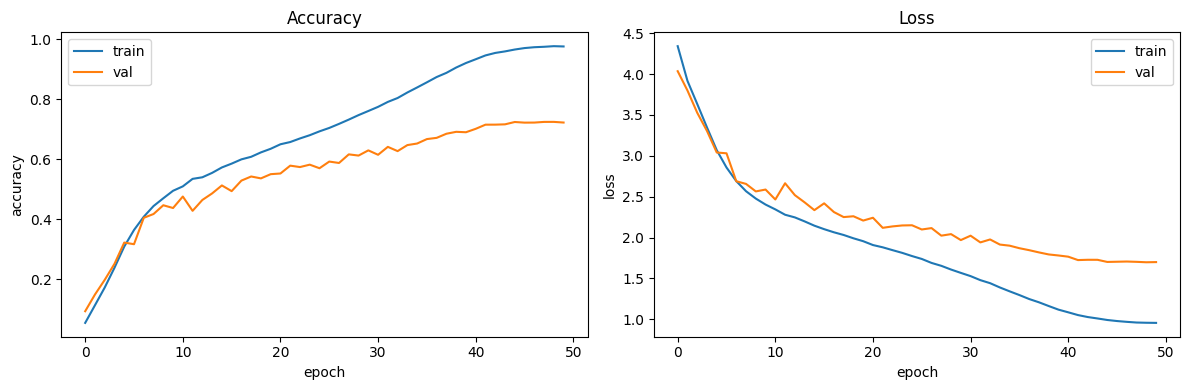

In [6]:
# Plot train/val accuracy and loss
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history["train_acc"], label="train")
ax1.plot(history["val_acc"],   label="val")
ax1.set_title("Accuracy")
ax1.set_xlabel("epoch")
ax1.set_ylabel("accuracy")
ax1.legend()

ax2.plot(history["train_loss"], label="train")
ax2.plot(history["val_loss"],   label="val")
ax2.set_title("Loss")
ax2.set_xlabel("epoch")
ax2.set_ylabel("loss")
ax2.legend()

plt.tight_layout()
plt.savefig("part1_deepcnn_curves.png", dpi=150)
plt.show()


## Part 2: Fine-Tune a Pretrained CNN

In [7]:
# Part 2: Fine-tune a pretrained ResNet-50 on CIFAR-100
# ResNet performs better with larger inputs, so resized to 64x64 as a middle ground.
# # RandomCrop + ColorJitter + RandomErasing improve OOD robustness.

def make_resnet_loaders(batch_size: int, num_workers: int):
    mean = (0.5071, 0.4867, 0.4408)
    std  = (0.2675, 0.2565, 0.2761)

    train_tfms = transforms.Compose([
        transforms.Resize(64),
        transforms.RandomCrop(64, padding=8),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
        transforms.RandomErasing(p=0.25),
    ])

    eval_tfms = transforms.Compose([
        transforms.Resize(64),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    train_full = datasets.CIFAR100(root=DATA_ROOT, train=True,  download=True, transform=train_tfms)
    test_ds    = datasets.CIFAR100(root=DATA_ROOT, train=False, download=True, transform=eval_tfms)

    n       = len(train_full)
    n_train = int(0.8 * n)
    n_val   = n - n_train

    val_full = datasets.CIFAR100(root=DATA_ROOT, train=True, download=False, transform=eval_tfms)
    train_ds, _ = torch.utils.data.random_split(train_full, [n_train, n_val],
                      generator=torch.Generator().manual_seed(SEED))
    _, val_ds   = torch.utils.data.random_split(val_full,   [n_train, n_val],
                      generator=torch.Generator().manual_seed(SEED))

    if IN_COLAB:
        num_workers = 0

    pin = torch.cuda.is_available()
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=num_workers, pin_memory=pin)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin)
    return train_loader, val_loader, test_loader

In [8]:
# ResNet-50 pretrained on ImageNet- freeze all layers first so pretrained weights aren't destroyed early.
# The original FC head (1000 ImageNet classes) is replaced with a 2-layer head for 100 CIFAR classes. 
def build_resnet(num_classes: int = 100, freeze_backbone: bool = True) -> nn.Module:
    # Load ResNet pretrained on imagenet
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    # Replace final FC layer 
    in_features = model.fc.in_features  
    model.fc = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, num_classes),
    )
    return model

In [9]:
# Two-phase fine-tuning:
# Phase 1 (5 epochs): only the new head trains.
# Fast and safe- head learns to map ImageNet features to CIFAR classes.

# Phase 2 (15 epochs): all layers unfreeze, full model trains with low LR (1e-4) to prevent overwriting.
# AdamW in phase 2 handles weight decay better

RESNET_CFG = {
    "batch_size"   : 128,
    "num_workers"  : 0,
    "phase1_epochs": 5,
    "phase2_epochs": 15,
    "phase1_lr"    : 1e-3,
    "phase2_lr"    : 1e-4,
    "weight_decay" : 1e-4,
}

set_seed(SEED)

resnet_train_loader, resnet_val_loader, resnet_test_loader = make_resnet_loaders(
    RESNET_CFG["batch_size"], RESNET_CFG["num_workers"]
)
resnet_model = build_resnet(num_classes=100, freeze_backbone=True).to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# ── Phase 1: head only 
print("=== Phase 1: training head only ===")
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, resnet_model.parameters()),
    lr=RESNET_CFG["phase1_lr"],
    weight_decay=RESNET_CFG["weight_decay"],
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=RESNET_CFG["phase1_epochs"]
)
resnet_history_p1 = fit(
    resnet_model, resnet_train_loader, resnet_val_loader,
    optimizer, criterion, device,
    epochs=RESNET_CFG["phase1_epochs"],
    scheduler=scheduler,
)

# ── Phase 2: full fine-tune
print("\n=== Phase 2: full model fine-tuning ===")
for param in resnet_model.parameters():
    param.requires_grad = True

optimizer = torch.optim.AdamW(
    resnet_model.parameters(),
    lr=RESNET_CFG["phase2_lr"],
    weight_decay=RESNET_CFG["weight_decay"],
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=RESNET_CFG["phase2_epochs"]
)
resnet_history_p2 = fit(
    resnet_model, resnet_train_loader, resnet_val_loader,
    optimizer, criterion, device,
    epochs=RESNET_CFG["phase2_epochs"],
    scheduler=scheduler,
)

resnet_history = {
    k: resnet_history_p1[k] + resnet_history_p2[k] for k in resnet_history_p1
}

print(f"\nFinal val acc: {max(resnet_history['val_acc']):.4f}")

=== Phase 1: training head only ===


train 1/5:   0%|          | 0/313 [00:00<?, ?it/s]

val 1/5:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 001/5 | train 0.1902 loss 3.7010 | val 0.2974 loss 3.1765


train 2/5:   0%|          | 0/313 [00:00<?, ?it/s]

...

val 14/15:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 014/15 | train 0.8933 loss 1.1880 | val 0.7868 loss 1.4507


train 15/15:   0%|          | 0/313 [00:00<?, ?it/s]

val 15/15:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 015/15 | train 0.8922 loss 1.1901 | val 0.7879 loss 1.4502
Best val acc: 0.7879

Final val acc: 0.7879


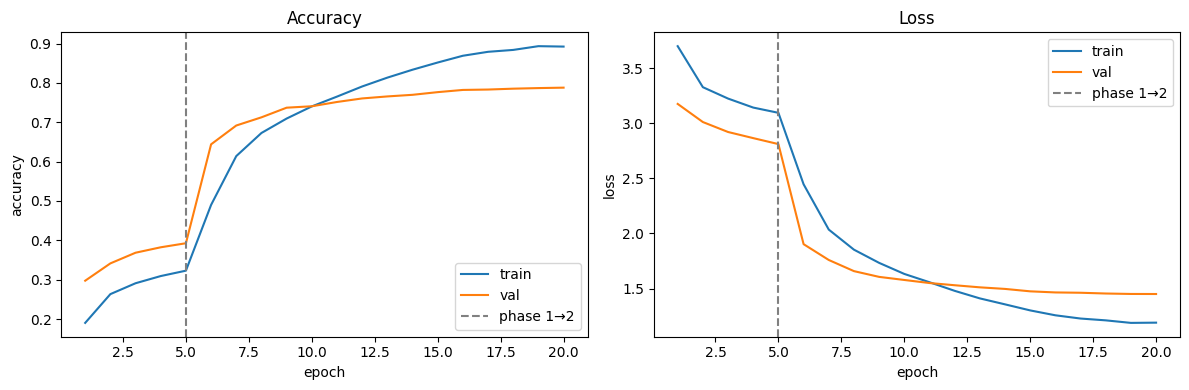

Best val acc: 0.7879


In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs_range = range(1, len(resnet_history["train_acc"]) + 1)

ax1.plot(epochs_range, resnet_history["train_acc"], label="train")
ax1.plot(epochs_range, resnet_history["val_acc"],   label="val")
ax1.axvline(x=RESNET_CFG["phase1_epochs"], color="gray", linestyle="--", label="phase 1→2")
ax1.set_title("Accuracy")
ax1.set_xlabel("epoch")
ax1.set_ylabel("accuracy")
ax1.legend()

ax2.plot(epochs_range, resnet_history["train_loss"], label="train")
ax2.plot(epochs_range, resnet_history["val_loss"],   label="val")
ax2.axvline(x=RESNET_CFG["phase1_epochs"], color="gray", linestyle="--", label="phase 1→2")
ax2.set_title("Loss")
ax2.set_xlabel("epoch")
ax2.set_ylabel("loss")
ax2.legend()

plt.tight_layout()
plt.savefig("part2_resnet_curves.png", dpi=150)
plt.show()
print(f"Best val acc: {max(resnet_history['val_acc']):.4f}")

## Part 3: Fine-Tune a Pretrained Transformer

In [11]:
# Part 3: Fine-tune a pretrained ViT on CIFAR-100- divides the image into 16x16 patches. 
# At 224x224 this gives 196 patches— the size the positional embeddings were trained for.

from torchvision.models import vit_b_16, ViT_B_16_Weights

# ViT-specific data loaders
def make_vit_loaders(batch_size: int, num_workers: int):
    mean = (0.5071, 0.4867, 0.4408)
    std  = (0.2675, 0.2565, 0.2761)

    # resize to 224 so the patch embedding layer works correctly.
    train_tfms = transforms.Compose([
        transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.RandAugment(num_ops=2, magnitude=9),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
        transforms.RandomErasing(p=0.4),
    ])

    # Val with no augmentation
    eval_tfms = transforms.Compose([
        transforms.Resize(256),           
        transforms.CenterCrop(224),      
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    train_full = datasets.CIFAR100(root=DATA_ROOT, train=True,  download=True, transform=train_tfms)
    test_ds    = datasets.CIFAR100(root=DATA_ROOT, train=False, download=True, transform=eval_tfms)

    n       = len(train_full)
    n_train = int(0.8 * n)
    n_val   = n - n_train
    g       = torch.Generator().manual_seed(SEED)
    train_ds, val_ds = torch.utils.data.random_split(train_full, [n_train, n_val], generator=g)

    # re-create val dataset with eval transforms to avoid augmenting validation
    val_full = datasets.CIFAR100(root=DATA_ROOT, train=True, download=False, transform=eval_tfms)
    _, val_ds = torch.utils.data.random_split(val_full, [n_train, n_val], generator=torch.Generator().manual_seed(SEED))

    if IN_COLAB:
        num_workers = 0

    pin = torch.cuda.is_available()
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=num_workers, pin_memory=pin)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin)
    return train_loader, val_loader, test_loader

In [12]:
# ViT pretrained on ImageNet
# The patch embedding layer splits each 224x224 image into 196 patches of 16x16 then processes them as a sequence using self-attention 
# Replaced the final head (1000 ImageNet classes) with a 2-layer MLP for 100 classes.
# freeze_backbone=True locks all transformer layers so only the head trains in phase 1.

def build_vit(num_classes: int = 100, freeze_backbone: bool = True) -> nn.Module:
    # Load ViT with pretrained weights
    model = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)

    if freeze_backbone:
        # only train the new head at first
        for param in model.parameters():
            param.requires_grad = False

    in_features = model.heads.head.in_features  
    model.heads.head = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, num_classes),
    )

    return model

In [13]:
# Two-phase fine-tuning for ViT:
# Phase 1 (5 epochs): backbone frozen, only the new classification head trains.
#   High LR (1e-3) is safe here since only the randomly initialized head updates.
# Phase 2 (10 epochs): full model unfreezes, trains with low LR (1e-4).
#   Low LR gently adjusts the pretrained transformer weights without destroying them.
# Checkpointing after phase 1 protects against disconnection during long phase 2.

VIT_CFG = {
    "batch_size"  : 64,
    "num_workers" : 0,
    "phase1_epochs": 5,
    "phase2_epochs": 20,
    "phase1_lr"   : 1e-3,
    "phase2_lr"   : 1e-4,
    "weight_decay": 1e-4,
}

set_seed(SEED)
device = get_device()

vit_train_loader, vit_val_loader, vit_test_loader = make_vit_loaders(
    VIT_CFG["batch_size"], VIT_CFG["num_workers"]
)
vit_model = build_vit(num_classes=100, freeze_backbone=True).to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# ── Phase 1: head only 
print("=== Phase 1: training head only ===")
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, vit_model.parameters()),
    lr=VIT_CFG["phase1_lr"],
    weight_decay=VIT_CFG["weight_decay"],
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=VIT_CFG["phase1_epochs"]
)
vit_history_p1 = fit(
    vit_model, vit_train_loader, vit_val_loader,
    optimizer, criterion, device,
    epochs=VIT_CFG["phase1_epochs"],
    scheduler=scheduler,
)
# Save as backup 
torch.save(vit_model.state_dict(), "vit_phase1.pt")
print("Phase 1 weights saved")

# ── Phase 2: full fine-tune
print("\n=== Phase 2: full model fine-tuning ===")
for param in vit_model.parameters():
    param.requires_grad = True

optimizer = torch.optim.AdamW(
    vit_model.parameters(),
    lr=VIT_CFG["phase2_lr"],
    weight_decay=VIT_CFG["weight_decay"],
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=VIT_CFG["phase2_epochs"]
)
vit_history_p2 = fit(
    vit_model, vit_train_loader, vit_val_loader,
    optimizer, criterion, device,
    epochs=VIT_CFG["phase2_epochs"],
    scheduler=scheduler,
)
# Save model
torch.save(vit_model.state_dict(), "vit_final.pt")
print("Final weights saved to vit_final.pt")

vit_history = {
    k: vit_history_p1[k] + vit_history_p2[k] for k in vit_history_p1
}
print(f"\nBest val acc: {max(vit_history['val_acc']):.4f}")

=== Phase 1: training head only ===


train 1/5:   0%|          | 0/625 [00:00<?, ?it/s]

val 1/5:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 001/5 | train 0.6201 loss 2.0469 | val 0.7613 loss 1.5441


train 2/5:   0%|          | 0/625 [00:00<?, ?it/s]

...

val 19/20:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 019/20 | train 0.9877 loss 0.8407 | val 0.8894 loss 1.1442


train 20/20:   0%|          | 0/625 [00:00<?, ?it/s]

val 20/20:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 020/20 | train 0.9877 loss 0.8426 | val 0.8890 loss 1.1428
Best val acc: 0.8894
Final weights saved to vit_final.pt

Best val acc: 0.8894


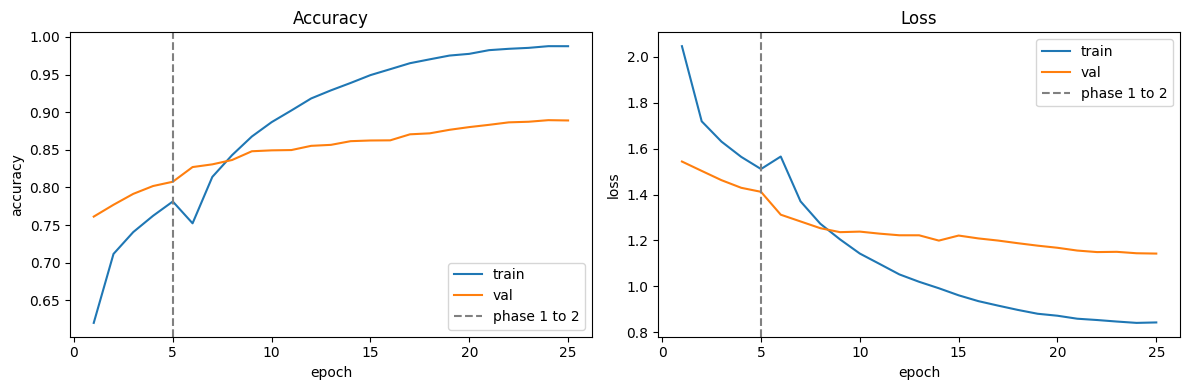

Best val acc: 0.8894


In [14]:
# Plot training curves for Part 3
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs_range = range(1, len(vit_history["train_acc"]) + 1)

ax1.plot(epochs_range, vit_history["train_acc"], label="train")
ax1.plot(epochs_range, vit_history["val_acc"],   label="val")
ax1.axvline(x=VIT_CFG["phase1_epochs"], color="gray", linestyle="--", label="phase 1 to 2")
ax1.set_title("Accuracy")
ax1.set_xlabel("epoch")
ax1.set_ylabel("accuracy")
ax1.legend()

ax2.plot(epochs_range, vit_history["train_loss"], label="train")
ax2.plot(epochs_range, vit_history["val_loss"],   label="val")
ax2.axvline(x=VIT_CFG["phase1_epochs"], color="gray", linestyle="--", label="phase 1 to 2")
ax2.set_title("Loss")
ax2.set_xlabel("epoch")
ax2.set_ylabel("loss")
ax2.legend()

plt.tight_layout()
plt.savefig("part3_vit_curves.png", dpi=150)
plt.show()
print(f"Best val acc: {max(vit_history['val_acc']):.4f}")

In [15]:
# ResizeWrapper adapts vit_model for OOD inference.
# OOD images are 32x32 and ViT needs 224x224. This wrapper resizes for the submission loop
class ResizeWrapper(nn.Module):
    def __init__(self, m):
        super().__init__()
        self.m = m
        self.resize = transforms.Resize(256)
        self.crop = transforms.CenterCrop(224)
        
    def forward(self, x):
        return self.m(self.crop(self.resize(x)))

model = ResizeWrapper(vit_model)

## OOD Submission Generation

This section creates `submission_ood.csv` for challenge evaluation.

Submission format:
- `id`: `distortionXX_severity_index`
- `label`: predicted class in `[0, 99]`


In [16]:
### DO NOT CHANGE THE BELOW, REPLACE WITH YOUR MODEL, THE SUBMISSION FILES NEED TO GO THROUGH THE BELOW PREPROCESSING

from huggingface_hub import snapshot_download

def ensure_ood_files(ood_dir: str) -> None:
    os.makedirs(ood_dir, exist_ok=True)
    print("Downloading OOD files from Hugging Face dataset...")
    snapshot_download(
        repo_id="XThomasBU/ood-test-CS541",
        repo_type="dataset",
        local_dir=ood_dir,
        local_dir_use_symlinks=False,
    )
    print("OOD files ready in", ood_dir)


@torch.no_grad()
def predict_file(model: nn.Module, npy_path: str, severity: int, batch_size: int) -> np.ndarray:
    images = np.load(npy_path, mmap_mode="r")
    start = (severity - 1) * 10000
    end = severity * 10000

    mean = (0.5071, 0.4867, 0.4408)
    std = (0.2675, 0.2565, 0.2761)
    normalize = transforms.Normalize(mean, std)

    preds = []
    model.eval()
    for b0 in tqdm(range(start, end, batch_size), desc=f"{os.path.basename(npy_path)} sev{severity}", leave=False):
        b1 = min(b0 + batch_size, end)
        xb_np = np.array(images[b0:b1], copy=True)
        xb = torch.from_numpy(xb_np).permute(0, 3, 1, 2).float().div(255.0)
        xb = normalize(xb).to(device, non_blocking=True)
        logits = model(xb)
        preds.append(logits.argmax(1).cpu().numpy())
    return np.concatenate(preds, axis=0)


ensure_ood_files(OOD_DIR)

distortion_files = sorted([p for p in os.listdir(OOD_DIR) if p.startswith("distortion") and p.endswith(".npy")])
print("Distortion files found:", len(distortion_files))

rows = []
BATCH = 64 if device.type == "cuda" else 32
for fname in distortion_files:
    dname = os.path.splitext(fname)[0]
    path = os.path.join(OOD_DIR, fname)
    for severity in [1, 2, 3, 4, 5]:
        pred = predict_file(model, path, severity, BATCH)
        for i, y in enumerate(pred.tolist()):
            rows.append((f"{dname}_{severity}_{i}", int(y)))
        print(f"{dname}_{severity} done")

submission = pd.DataFrame(rows, columns=["id", "label"])
submission.to_csv(SUBMISSION_PATH, index=False)
print("Wrote", SUBMISSION_PATH, "rows:", len(submission))


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `snapshot_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Fetching 21 files:   0%|          | 0/21 [00:00<?, ?it/s]

OOD files ready in /teamspace/studios/this_studio/temp_student/ood-test-CS541
Distortion files found: 20


distortion00.npy sev1:   0%|          | 0/157 [00:00<?, ?it/s]

distortion00_1 done


...

distortion_19_3 done


distortion_19.npy sev4:   0%|          | 0/157 [00:00<?, ?it/s]

distortion_19_4 done


distortion_19.npy sev5:   0%|          | 0/157 [00:00<?, ?it/s]

distortion_19_5 done
Wrote /teamspace/studios/this_studio/temp_student/submission_ood.csv rows: 1000000


In [17]:
# Get class names directly from the dataset
import matplotlib.pyplot as plt
dataset = datasets.CIFAR100(root=DATA_ROOT, train=True, download=False)
cifar100_classes = dataset.classes


# Get all predictions and true labels on the val set
vit_model.eval()
all_preds = []
all_labels = []
all_logits = []

with torch.no_grad():
    for x, y in vit_val_loader:
        x, y = x.to(device), y.to(device)
        logits = vit_model(x)
        all_preds.append(logits.argmax(1).cpu())
        all_labels.append(y.cpu())
        all_logits.append(logits.cpu())

all_preds  = torch.cat(all_preds)
all_labels = torch.cat(all_labels)
all_logits = torch.cat(all_logits)

# Per-class accuracy
class_correct = torch.zeros(100)
class_total   = torch.zeros(100)
for p, l in zip(all_preds, all_labels):
    class_total[l] += 1
    if p == l:
        class_correct[l] += 1

class_acc = class_correct / class_total.clamp(min=1)

# Top 3 worst classes
worst3_idx = class_acc.argsort()[:3]
print("Top 3 worst-performing classes:")
for idx in worst3_idx:
    print(f"  {cifar100_classes[idx]:20s} acc: {class_acc[idx]:.2%}")

# Top 3 highest-confidence wrong predictions
wrong_mask = all_preds != all_labels
wrong_logits  = all_logits[wrong_mask]
wrong_preds   = all_preds[wrong_mask]
wrong_labels  = all_labels[wrong_mask]

wrong_conf = torch.softmax(wrong_logits, dim=1).max(dim=1).values
top3_conf_idx = wrong_conf.argsort(descending=True)[:3]

print("\nTop 3 highest-confidence wrong predictions:")
for rank, idx in enumerate(top3_conf_idx):
    true_cls = cifar100_classes[wrong_labels[idx]]
    pred_cls = cifar100_classes[wrong_preds[idx]]
    conf     = wrong_conf[idx].item()
    print(f"  Rank {rank + 1}: true= {true_cls:20s} predicted= {pred_cls:20s} confidence= {conf:.2%}")

Top 3 worst-performing classes:
  boy                  acc: 59.18%
  girl                 acc: 64.21%
  oak_tree             acc: 70.65%

Top 3 highest-confidence wrong predictions:
  Rank 1: true= forest               predicted= sweet_pepper         confidence= 96.88%
  Rank 2: true= spider               predicted= crab                 confidence= 95.90%
  Rank 3: true= tulip                predicted= orchid               confidence= 95.66%
